# 04_Modeling

Objectifs :
- Préparer les données pour le ML (encodage, split, gestion du déséquilibre)
- Entraîner et comparer plusieurs modèles
- Évaluer les performances (metrics adaptées)
- Analyser les features les plus importantes

Ce notebook part du dataset exporté à la fin du notebook 03 (1 ligne = 1 accident) et vise une **classification multiclasse** sur `target_grav` (1 = blessé léger, 2 = blessé hospitalisé, 3 = tué).

## Imports des librairies et des données
On utilise principalement des modèles à base d'arbres (RandomForest, XGBoost, LightGBM, CatBoost). Ils sont adaptés à des variables numériques/booléennes et capturent des relations non linéaires.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib
from pathlib import Path

On charge le fichier exporté à la fin du notebook 03 (par exemple `../data/processed/accidents_model_day4.csv`).

Attendu :
- `target_grav` est la cible multiclasse (1/2/3)
- les colonnes `saison_*` sont déjà one-hot
- les features sont numériques/bool

In [2]:
DATA_PATH = "../data/processed/accidents_model.csv"

In [3]:
df_model = pd.read_csv(DATA_PATH)

In [4]:
df_model.shape

(160856, 17)

In [5]:
df_model.head()

,Num_Acc,target_grav,is_grave,acc_est_en_agglo,intersection,luminosite,cond_atmo,etat_surface,vitesse_max_auto_clean,nbre_voies_circu,route_rapide,infra_complexe,periode_jour_nuit_bin,saison_Automne,saison_Ete,saison_Hiver,saison_Printemps
0,202200000001,2,True,True,3.0,1.0,1.0,1.0,50.0,2.0,False,True,0,True,False,False,False
1,202200000002,1,False,True,3.0,1.0,1.0,1.0,50.0,2.0,False,True,0,True,False,False,False
2,202200000003,1,False,True,6.0,1.0,1.0,1.0,50.0,2.0,False,True,0,True,False,False,False
3,202200000004,1,False,True,3.0,1.0,8.0,1.0,30.0,1.0,False,True,0,True,False,False,False
4,202200000005,1,False,False,1.0,1.0,1.0,1.0,80.0,2.0,True,False,0,True,False,False,False


### Vérifications rapides

- 1 ligne = 1 accident (Num_Acc unique)
- distribution de la cible
- vérifier les types de colonnes


In [6]:
print("Num_Acc unique ? ", df_model["Num_Acc"].is_unique)

Num_Acc unique ?  True


In [7]:
print("\nDistribution target_grav (%)")
print((df_model["target_grav"].value_counts(normalize=True).sort_index() * 100).round(2))


Distribution target_grav (%)
target_grav
1    64.40
2    29.79
3     5.81
Name: proportion, dtype: float64


In [8]:
df_model.dtypes

Num_Acc                     int64
target_grav                 int64
is_grave                     bool
acc_est_en_agglo             bool
intersection              float64
luminosite                float64
cond_atmo                 float64
etat_surface              float64
vitesse_max_auto_clean    float64
nbre_voies_circu          float64
route_rapide                 bool
infra_complexe               bool
periode_jour_nuit_bin       int64
saison_Automne               bool
saison_Ete                   bool
saison_Hiver                 bool
saison_Printemps             bool
dtype: object

## Définir la cible et les features

On fait une classification multiclasse sur `target_grav`.

Important : on enlève de X tout ce qui n'est pas une feature (identifiant, cibles).

In [9]:
TARGET_COL = "target_grav"

In [10]:
# Colonnes à exclure de X
cols_to_drop = ["Num_Acc", "target_grav", "is_grave"]

In [11]:
X = df_model.drop(columns=cols_to_drop)

In [12]:
y = df_model[TARGET_COL]

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (160856, 14)
y shape: (160856,)


In [14]:
X.head()

,acc_est_en_agglo,intersection,luminosite,cond_atmo,etat_surface,vitesse_max_auto_clean,nbre_voies_circu,route_rapide,infra_complexe,periode_jour_nuit_bin,saison_Automne,saison_Ete,saison_Hiver,saison_Printemps
0,True,3.0,1.0,1.0,1.0,50.0,2.0,False,True,0,True,False,False,False
1,True,3.0,1.0,1.0,1.0,50.0,2.0,False,True,0,True,False,False,False
2,True,6.0,1.0,1.0,1.0,50.0,2.0,False,True,0,True,False,False,False
3,True,3.0,1.0,8.0,1.0,30.0,1.0,False,True,0,True,False,False,False
4,False,1.0,1.0,1.0,1.0,80.0,2.0,True,False,0,True,False,False,False


In [15]:
X.dtypes

acc_est_en_agglo             bool
intersection              float64
luminosite                float64
cond_atmo                 float64
etat_surface              float64
vitesse_max_auto_clean    float64
nbre_voies_circu          float64
route_rapide                 bool
infra_complexe               bool
periode_jour_nuit_bin       int64
saison_Automne               bool
saison_Ete                   bool
saison_Hiver                 bool
saison_Printemps             bool
dtype: object

In [16]:
y.dtypes

dtype('int64')

Certains modèles (notamment XGBoost) attendent des labels de classes encodés de 0 à K-1. La cible `target_grav` étant codée 1/2/3, on crée une version encodée `y_enc = target_grav - 1` pour l’entraînement.

In [17]:
# Cible originale (1,2,3)
y = df_model["target_grav"]

In [18]:
# Version encodée pour certains modèles (0,1,2)
y_enc = y - 1

print("Classes y:", sorted(y.unique()))
print("Classes y_enc:", sorted(y_enc.unique()))

Classes y: [np.int64(1), np.int64(2), np.int64(3)]
Classes y_enc: [np.int64(0), np.int64(1), np.int64(2)]


**Remarque** : pour l’entraînement, la cible est encodée en 0/1/2 (y_enc = target_grav - 1). Cela signifie : 0 = blessé léger (gravité 1), 1 = hospitalisé (gravité 2), 2 = tué (gravité 3). Les métriques affichées plus bas utilisent cet encodage.

## Train/Test split

Comme la classe 3 (tué) est rare, on fait un split stratifié pour garder les mêmes proportions dans train et test.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

In [20]:
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (128684, 14)  Test: (32172, 14)


In [21]:
print("\nDistribution y_train (%)")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nDistribution y_test (%)")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))


Distribution y_train (%)
target_grav
0    64.40
1    29.79
2     5.81
Name: proportion, dtype: float64

Distribution y_test (%)
target_grav
0    64.40
1    29.79
2     5.81
Name: proportion, dtype: float64


## Baseline

Avant de tester des modèles plus complexes, on compare à un modèle très simple :
- `DummyClassifier(strategy='most_frequent')` prédit toujours la classe la plus fréquente.

Ça donne un repère : si nos modèles font à peine mieux, c'est un signal d'alerte.

In [22]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)

In [23]:
dummy.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [24]:
y_pred = dummy.predict(X_test)

In [25]:
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 3))

Balanced accuracy: 0.333


In [26]:
print("F1 macro:", round(f1_score(y_test, y_pred, average="macro"), 3))

F1 macro: 0.261


In [27]:
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=3))


Classification report:

              precision    recall  f1-score   support

           0      0.644     1.000     0.783     20718
           1      0.000     0.000     0.000      9585
           2      0.000     0.000     0.000      1869

    accuracy                          0.644     32172
   macro avg      0.215     0.333     0.261     32172
weighted avg      0.415     0.644     0.505     32172



C:\Users\cracm\anaconda3\envs\brief-predire-gravite-accidents\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cracm\anaconda3\envs\brief-predire-gravite-accidents\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cracm\anaconda3\envs\brief-predire-gravite-accidents\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Création des modèles

- **RandomForest** : modèle robuste et simple à utiliser.  
  - `n_estimators=300` : nombre d’arbres. Plus il y en a, plus le modèle est stable (mais plus c’est long).  
  - `class_weight="balanced"` : donne plus de poids aux classes rares (utile car la classe "tué" est minoritaire).  
  - `n_jobs=-1` : utilise tous les cœurs du CPU pour aller plus vite.

In [28]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

- **XGBoost** : modèle de boosting souvent performant sur des datasets structurés.  
  - `n_estimators=800` et `learning_rate=0.05` : on utilise plus d’arbres mais un apprentissage plus “progressif”.  
  - `max_depth=6` : limite la complexité de chaque arbre.  
  - `subsample` et `colsample_bytree` à 0.9 : introduit un peu d’aléatoire pour réduire le sur-apprentissage.  
  - `objective="multi:softprob"` : classification multiclasse.

In [29]:
xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

- **LightGBM** : autre modèle de boosting, souvent très rapide et efficace.  
  - `n_estimators=2000` et `learning_rate=0.03` : même logique (plus d’arbres, apprentissage plus doux).  
  - `num_leaves=31` : contrôle la complexité des arbres.  
  - `subsample` et `colsample_bytree` à 0.9 : limite le sur-apprentissage.

In [30]:
lgbm = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

- **CatBoost** : modèle de boosting qui fonctionne souvent bien avec peu de réglages.  
  - `iterations=2000` : nombre d’itérations (arbres).  
  - `learning_rate=0.05` et `depth=6` : réglages simples pour contrôler la complexité.  
  - `verbose=False` : pour éviter trop de logs dans le notebook.

In [31]:
cat = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

## Entraînement des modèles

### Métriques d'évaluation utilisées

Dans ce projet, la variable cible `target_grav` est déséquilibrée : certaines classes (notamment la classe “tué”) sont beaucoup plus rares que d’autres. Les métriques classiques comme l’accuracy ou le F1 “global” peuvent donc être trompeuses.

C’est pourquoi nous utilisons le F1 macro et la balanced accuracy.

#### Accuracy vs Balanced accuracy

L’accuracy mesure la proportion totale de prédictions correctes. Elle fonctionne bien lorsque les classes sont équilibrées, mais devient trompeuse en présence de classes rares.

Dans notre cas, la majorité des accidents sont des blessés légers. Un modèle qui prédirait presque toujours cette classe obtiendrait une bonne accuracy, tout en étant incapable de détecter correctement les accidents graves.

La balanced accuracy corrige ce problème en calculant la moyenne du rappel de chaque classe. Chaque niveau de gravité a donc le même poids, quelle que soit sa fréquence.

Dans ce projet, la balanced accuracy est plus pertinente que l’accuracy classique, car elle reflète mieux la capacité du modèle à reconnaître tous les niveaux de gravité.

#### F1 global vs F1 macro

Le F1-score global est dominé par les classes les plus fréquentes. Il peut donc donner une bonne impression de performance même si le modèle échoue sur les classes rares.

Le F1 macro calcule un F1-score pour chaque classe, puis en fait la moyenne sans pondération. Chaque classe contribue de manière égale au score final.

Le F1 macro est donc plus adapté à ce projet, car il pénalise les modèles qui ne parviennent pas à prédire correctement les accidents les plus graves.

In [ ]:
# On stocke les modèles dans un dictionnaire
models = {
    "RandomForest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

In [33]:
labels = sorted(np.unique(y_test))

In [34]:
results = []

Modèle : RandomForest
Balanced accuracy: 0.468
F1 macro: 0.41

Classification report:

              precision    recall  f1-score   support

           0      0.753     0.725     0.739     20718
           1      0.395     0.233     0.293      9585
           2      0.127     0.445     0.197      1869

    accuracy                          0.562     32172
   macro avg      0.425     0.468     0.410     32172
weighted avg      0.610     0.562     0.575     32172



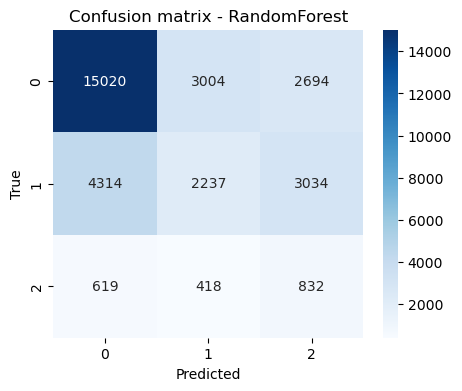

Modèle : XGBoost
Balanced accuracy: 0.421
F1 macro: 0.413

Classification report:

              precision    recall  f1-score   support

           0      0.724     0.903     0.804     20718
           1      0.546     0.359     0.433      9585
           2      0.120     0.002     0.003      1869

    accuracy                          0.689     32172
   macro avg      0.463     0.421     0.413     32172
weighted avg      0.636     0.689     0.647     32172



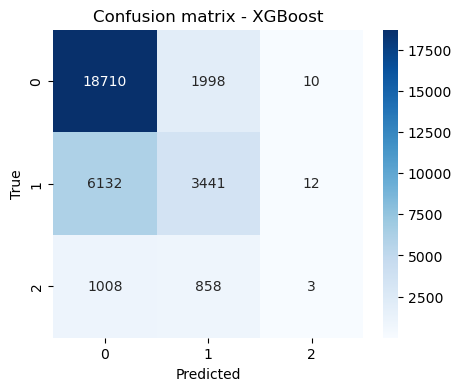

Modèle : LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 75
[LightGBM] [Info] Number of data points in the train set: 128684, number of used features: 14
[LightGBM] [Info] Start training from score -0.440123
[LightGBM] [Info] Start training from score -1.210840
[LightGBM] [Info] Start training from score -2.845662
Balanced accuracy: 0.421
F1 macro: 0.413

Classification report:

              precision    recall  f1-score   support

           0      0.723     0.904     0.803     20718
           1      0.547     0.356     0.432      9585
           2      0.156     0.003     0.005      1869

    accuracy                          0.688     32172
   macro avg      0.476     0.421     0.413     32172
weighted avg      0.638     0.688     0.646     32172



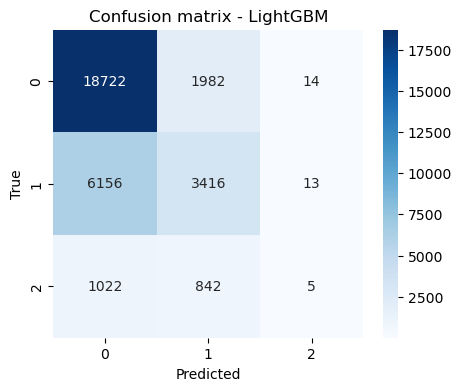

Modèle : CatBoost
Balanced accuracy: 0.419
F1 macro: 0.41

Classification report:

              precision    recall  f1-score   support

           0      0.721     0.909     0.804     20718
           1      0.551     0.347     0.426      9585
           2      0.062     0.001     0.001      1869

    accuracy                          0.689     32172
   macro avg      0.445     0.419     0.410     32172
weighted avg      0.632     0.689     0.645     32172



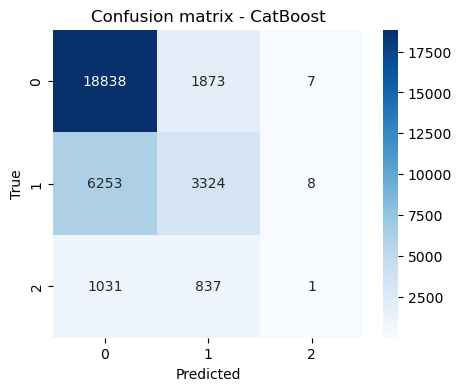

In [35]:
for name, model in models.items():
    print("=" * 70)
    print(f"Modèle : {name}")

    # Entraînement
    model.fit(X_train, y_train)

    # Prédiction
    y_pred = model.predict(X_test)

    # Métriques globales
    f1m = f1_score(y_test, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_test, y_pred)

    print("Balanced accuracy:", round(bacc, 3))
    print("F1 macro:", round(f1m, 3))

    # Classification report
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred, digits=3))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels
    )
    plt.title(f"Confusion matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Sauvegarde des scores pour comparer ensuite
    results.append({
        "model": name,
        "f1_macro": f1m,
        "balanced_accuracy": bacc
    })

In [36]:
df_results = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
df_results

,model,f1_macro,balanced_accuracy
2,LightGBM,0.413397,0.420908
1,XGBoost,0.413348,0.421228
3,CatBoost,0.410351,0.418862
0,RandomForest,0.409839,0.467839


In [37]:
best_name = df_results.iloc[0]["model"]
print("Meilleur modèle (selon F1 macro):", best_name)

best_model = models[best_name]

Meilleur modèle (selon F1 macro): LightGBM


## Analyse comparative des modèles

Nous avons comparé quatre modèles de classification multiclasse :
1. RandomForest
2. XGBoost
3. LightGBM
4. CatBoost

Les performances ont été évaluées à l’aide de métriques adaptées à un problème de classes déséquilibrées :
- F1 macro
- Balanced accuracy
- Classification report par classe
- Matrices de confusion

**Rappel sur la distribution des classes**

La variable cible `target_grav` est déséquilibrée :
- Classe 1 (blessé léger) : environ 64 %
- Classe 2 (hospitalisé) : environ 30 %
- Classe 3 (tué) : environ 6 %

Cela signifie qu’un modèle peut obtenir une bonne accuracy globale tout en étant mauvais sur les classes graves.

### Analyse par modèle

#### RandomForest

- Balanced accuracy : 0.47 (la plus élevée)
- F1 macro : 0.41
- Meilleur rappel sur la classe 3 (tué)

Interprétation :
- le RandomForest est le modèle qui équilibre le mieux les classes
- il détecte mieux les accidents les plus graves
- en contrepartie, son accuracy globale est plus faible

#### XGBoost

- Balanced accuracy : 0.42
- F1 macro : 0.41
- Très bonne performance sur la classe 1
- Très faible rappel sur la classe 3

Interprétation :
- le modèle est performant globalement
- mais il échoue presque totalement à détecter les accidents mortels
- ce comportement est problématique pour l’objectif métier

#### LightGBM

- Balanced accuracy : 0.42
- F1 macro : 0.41 (meilleure valeur)
- Résultats très proches de XGBoost

Interprétation :
- LightGBM offre le meilleur compromis global selon le F1 macro
- cependant, comme XGBoost, il reste très faible sur la classe 3

#### CatBoost

- Balanced accuracy : 0.42
- F1 macro : 0.41
- Comportement très similaire à XGBoost et LightGBM

Interprétation :
- pas d’avantage significatif dans cette configuration
- performances proches mais pas supérieures

### Comparaison finale

| Modèle       | F1 macro | Balanced accuracy |
| ------------ | -------- | ----------------- |
| LightGBM     | ~0.413   | ~0.421            |
| XGBoost      | ~0.413   | ~0.421            |
| CatBoost     | ~0.410   | ~0.419            |
| RandomForest | ~0.410   | ~0.468            |

- LightGBM est le meilleur selon le F1 macro
- RandomForest est le meilleur selon la balanced accuracy
- aucun modèle ne parvient à bien prédire la classe “tué”

### Choix du modèle

Dans ce projet, le F1 macro a été retenu comme métrique principale car il donne le même poids à chaque classe.

Le modèle LightGBM est donc sélectionné comme meilleur modèle à ce stade.

## Fine-tuning du modèle LightGBM

Après la comparaison des modèles, on cherche à améliorer LightGBM avec un réglage simple des hyperparamètres.

### Créer un jeu de validation

On garde le jeu de test (`X_test`, `y_test`) uniquement pour l’évaluation finale.  
Pour ajuster les paramètres, on découpe une partie du train en validation :

- `X_tr`, `y_tr` : entraînement
- `X_val`, `y_val` : validation

Cela évite de choisir des paramètres en regardant les résultats du test (ce qui fausserait l’évaluation).

In [38]:
# Split interne pour le tuning (on garde X_test,y_test à part)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [39]:
print("Train interne:", X_tr.shape)
print("Validation:", X_val.shape)

Train interne: (102947, 14)
Validation: (25737, 14)


### Agir sur le déséquilibre des classes et tester la complexité du modèle avec `num_leaves`

Comme la classe “tué” est rare, on utilise `class_weight="balanced"`. Cela donne plus d’importance aux classes minoritaires pendant l’apprentissage.

`num_leaves` contrôle la complexité des arbres :
- plus petit : modèle plus simple, risque de sous-apprentissage
- plus grand : modèle plus complexe, risque de sur-apprentissage

On teste quelques valeurs (15, 31, 63) et on compare les résultats sur la validation.

In [40]:
# On teste 3 niveaux de complexité
# (15 = plus simple, 31 = standard, 63 = plus complexe)
for nl in [15, 31, 63]:
    print("=" * 70)
    print("Test num_leaves =", nl)

    lgbm = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=nl,
        class_weight="balanced",
        random_state=42
    )

    lgbm.fit(X_tr, y_tr)
    y_pred_val = lgbm.predict(X_val)

    print("F1 macro (val):", round(f1_score(y_val, y_pred_val, average="macro"), 3))
    print("Balanced acc (val):", round(balanced_accuracy_score(y_val, y_pred_val), 3))
    print("\nReport (val):\n")
    print(classification_report(y_val, y_pred_val, digits=3))

Test num_leaves = 15
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 75
[LightGBM] [Info] Number of data points in the train set: 102947, number of used features: 14
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
F1 macro (val): 0.417
Balanced acc (val): 0.494

Report (val):

              precision    recall  f1-score   support

           0      0.774     0.707     0.739     16574
           1      0.401     0.239     0.299      7668
           2      0.133     0.538     0.214      1495

    accuracy                          0.558     25737
   macro avg      0.436     0.494     0.417     25737
weighted avg      0.626     0.558     0.577     25737

Test num_leaves = 31

### Tester une régularisation simple (`min_child_samples`)

`min_child_samples` indique le nombre minimum d’observations dans une feuille :
- plus grand : modèle plus régularisé (moins de sur-apprentissage)
- plus petit : modèle plus flexible

On teste plusieurs valeurs (10, 20, 50).

In [41]:
# On prend une valeur de num_leaves qui a l'air correcte (ici 15), puis on teste quelques min_child_samples
for mcs in [10, 20, 50]:
    print("=" * 70)
    print("Test min_child_samples =", mcs)

    lgbm = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=mcs,
        class_weight="balanced",
        random_state=42
    )

    lgbm.fit(X_tr, y_tr)
    y_pred_val = lgbm.predict(X_val)

    print("F1 macro (val):", round(f1_score(y_val, y_pred_val, average="macro"), 3))
    print("Balanced acc (val):", round(balanced_accuracy_score(y_val, y_pred_val), 3))
    print("\nReport (val):\n")
    print(classification_report(y_val, y_pred_val, digits=3))

Test min_child_samples = 10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 75
[LightGBM] [Info] Number of data points in the train set: 102947, number of used features: 14
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
F1 macro (val): 0.416
Balanced acc (val): 0.494

Report (val):

              precision    recall  f1-score   support

           0      0.774     0.709     0.740     16574
           1      0.402     0.233     0.295      7668
           2      0.132     0.540     0.213      1495

    accuracy                          0.558     25737
   macro avg      0.436     0.494     0.416     25737
weighted avg      0.626     0.558     0.577     25737

Test min_chil

### Entraîner le meilleur modèle sur tout le train, puis évaluer sur le test

Une fois les meilleurs paramètres choisis sur la validation, on ré-entraîne LightGBM sur tout `X_train` et on évalue une seule fois sur `X_test`. Cela donne une estimation plus fiable des performances finales.

In [42]:
best_num_leaves = 15
best_min_child_samples = 20

best_lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=best_num_leaves,
    min_child_samples=best_min_child_samples,
    class_weight="balanced",
    random_state=42
)

best_lgbm.fit(X_train, y_train)
y_pred_test = best_lgbm.predict(X_test)

print("F1 macro (test):", round(f1_score(y_test, y_pred_test, average="macro"), 3))
print("Balanced acc (test):", round(balanced_accuracy_score(y_test, y_pred_test), 3))
print("\nReport (test):\n")
print(classification_report(y_test, y_pred_test, digits=3))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 75
[LightGBM] [Info] Number of data points in the train set: 128684, number of used features: 14
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
F1 macro (test): 0.411
Balanced acc (test): 0.493

Report (test):

              precision    recall  f1-score   support

           0      0.772     0.716     0.743     20718
           1      0.396     0.213     0.277      9585
           2      0.131     0.549     0.212      1869

    accuracy                          0.557     32172
   macro avg      0.433     0.493     0.411     32172
weighted avg      0.623     0.557     0.573     32172



## Conclusion

L’objectif de ce notebook était d’entraîner et d’évaluer plusieurs modèles de classification afin de prédire la gravité d’un accident de la route à partir de ses caractéristiques.

### Synthèse de la démarche

1. Les données préparées lors du jour 3 ont été utilisées pour un problème de classification multiclasse, avec trois niveaux de gravité.
2. Les données ont été séparées en un jeu d’entraînement et un jeu de test, en conservant la distribution des classes grâce à un split stratifié.
3. Plusieurs modèles adaptés aux données tabulaires ont été comparés :
   * RandomForest
   * XGBoost
   * LightGBM
   * CatBoost
4. Les performances ont été évaluées avec des métriques adaptées à un problème de classes déséquilibrées :
   * F1 macro
   * Balanced accuracy
   * Matrices de confusion

### Résultats principaux

* Le modèle naïf (DummyClassifier) montre que prédire uniquement la classe majoritaire donne de très mauvaises performances sur les classes graves.
* Les modèles de boosting (XGBoost, LightGBM, CatBoost) obtiennent de bons scores globaux, mais ont initialement beaucoup de difficultés à détecter la classe la plus grave (accidents mortels).
* Le RandomForest présente une meilleure balanced accuracy, ce qui signifie qu’il équilibre mieux les classes, mais avec un F1 macro légèrement inférieur.

### Choix et amélioration du modèle

Le modèle LightGBM a été retenu comme meilleur compromis selon le F1 macro, qui donne le même poids à chaque classe.

Un fine-tuning simple a ensuite été réalisé :

* ajout d’une pondération des classes (`class_weight="balanced"`)
* ajustement de la complexité du modèle (`num_leaves`)
* régularisation via `min_child_samples`

Ce réglage permet d’améliorer significativement la détection des classes graves, en particulier la classe “tué”, tout en conservant de bonnes performances globales.

### Limites et perspectives

Malgré ces améliorations, la prédiction des accidents les plus graves reste difficile, en raison :

* du fort déséquilibre des classes,
* de l’absence de certaines informations contextuelles (météo, trafic, temps d’intervention des secours).

Des pistes d’amélioration possibles seraient :

* l’intégration de données externes (météo, géolocalisation des urgences),
* des techniques de rééquilibrage plus avancées,
* un fine-tuning plus approfondi des hyperparamètres.

### Suite du projet

À l’issue de ce notebook :

* un modèle entraîné et sélectionné est disponible,
* les features utilisées sont clairement identifiées.

La prochaine étape consiste à déployer ce modèle via une API REST et à créer une interface web permettant de tester des scénarios d’accidents et d’afficher la prédiction de gravité.

## Export du modèle

In [44]:
Path("../models").mkdir(exist_ok=True)

In [45]:
joblib.dump(best_lgbm, "../models/best_model_multiclass.joblib")

['../models/best_model_multiclass.joblib']

In [46]:
pd.Series(X.columns, name="feature").to_csv("../models/model_features.csv", index=False)